## 효과 분해: 모델 효과 vs 변수 효과

① 선형×47(5-means+Ridge, k=7) <br>
② 트리×47(CatBoost, control) <br>
③ 트리×122(CatBoost, full, 챔피언) <br>

세 모델의 예측값을 불러와 모형 효과(②−①)와 변수 효과(③−②)를 부트스트랩으로 분해하고, 챔피언 모델(CatBoost×122)의 승인 컷오프를 확정한 뒤, 등급 내부 판별력(AUC)과 재분류 분석까지 이어서 진행한다. 

<br>

**목차**
1. ①②③ 예측값 준비 및 점검 <br>
2. 효과 분해 (Ablation) <br>
3. 부도 정의 확정 <br>
4. 컷오프 값 결정 <br>
5. 기존 등급체계 대비 추가 선별력 (AUC) <br>
6. 승인건 부도율 비교 <br>
7. 재분류 분석 <br>
8. 최종 요약

### 1. ①②③ 예측값 준비 및 점검
앞선 실험에서 최종 확정한 모델을 재현한다.

#### 1-1. 선형 챔피언(①) 재현
K-Means + Ridge (k=7)

In [1]:
import numpy as np
import pandas as pd
import pickle
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df_lin = pd.read_csv("model_input_linear.csv")

NOT_FEATURE = ["id", "split", "grade", "term_n", "funded_amnt", "rf", "irr",
               "excess", "excess_contract", "spread_positive", "bad"]
feature_cols = [c for c in df_lin.columns if c not in NOT_FEATURE]

train_lin = df_lin[df_lin["split"] == "train"]
val_lin   = df_lin[df_lin["split"] == "val"]

X_train_lin = train_lin[feature_cols]
X_val_lin   = val_lin[feature_cols]
y_train_cont = train_lin["excess"]
excess_val   = val_lin["excess"].values
val_ids_lin  = val_lin["id"].values
grade_val    = val_lin["grade"].values

print(f"feature 수: {len(feature_cols)} (47이어야 정상)")
print(f"X_val_lin shape: {X_val_lin.shape}")

feature 수: 47 (47이어야 정상)
X_val_lin shape: (143593, 47)


In [2]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lin)
X_val_scaled   = scaler.transform(X_val_lin)

kmeans7 = KMeans(n_clusters=7, random_state=42, n_init=10)
train_cluster = kmeans7.fit_predict(X_train_scaled)
val_cluster   = kmeans7.predict(X_val_scaled)

cluster_models = {}
for c in range(7):
    mask = train_cluster == c
    m = Ridge(alpha=12.867193557921818)
    m.fit(X_train_lin[mask], y_train_cont[mask])
    cluster_models[c] = m

pred_lin47 = np.zeros(len(X_val_lin))
for c in range(7):
    mask = val_cluster == c
    if mask.sum() > 0:
        pred_lin47[mask] = cluster_models[c].predict(X_val_lin[mask])

print("pred_lin47 준비 완료:", pred_lin47.shape)

pred_lin47 준비 완료: (143593,)


#### 1-2. ②, ③: 트리 모델 예측값 로드
- `pred_tree47_final.pkl` = 트리×47(control), `pred_tree122_final.pkl` = 트리×122(full, 챔피언 모델).

In [3]:
with open("pred_tree47_final.pkl", "rb") as f:
    pred_tree47 = pickle.load(f)
with open("pred_tree122_final.pkl", "rb") as f:
    pred_tree122 = pickle.load(f)

#### 1-3. 정합성 확인
세 예측값이 같은 val행 순서인지 확인한다.

In [4]:
assert len(pred_lin47) == len(excess_val) == len(pred_tree47) == len(pred_tree122), \
    "길이가 다릅니다 — val 행 수 불일치"

df_tree_ids = pd.read_csv("model_input_tree.csv", usecols=["id", "split"])
val_ids_tree = df_tree_ids[df_tree_ids["split"] == "val"]["id"].values

if np.array_equal(val_ids_lin, val_ids_tree):
    print("✅ 선형용/트리용 val id 순서 완전 일치: 그대로 진행 가능")
else:
    n_diff = np.sum(val_ids_lin != val_ids_tree) if len(val_ids_lin) == len(val_ids_tree) else None
    print("🚨 val id 순서 불일치! 정렬 후 사용해야 함.")
    print(f"   길이: 선형 {len(val_ids_lin)} / 트리 {len(val_ids_tree)}")
    if n_diff is not None:
        print(f"   다른 위치 개수: {n_diff}")

✅ 선형용/트리용 val id 순서 완전 일치: 그대로 진행 가능


#### 1-4. 각 실험 val Sharpe 재확인 

아래 결과에 나오는 승인률(예: ①번 40%)은 각 실험이 각자 가장 좋은 성능을 내는 지점으로, 예측값이 파일에서 올바르게 로드됐는지(기대값과 일치하는지) 확인하는 용도이며, 아래 아래 절(decompose)에서는 세 실험 모두 **pct=45%로 통일**해서 다시 계산한다. 즉 여기서 ①번이 40%로 나온 것과 4번에서 45%를 쓰는 것은 서로 다른 목적이라 모순되지 않는다.

In [5]:
def sharpe(pred, excess, pct):
    thr = np.quantile(pred, 1 - pct)
    x = np.where(pred >= thr, excess, 0.0)
    sd = x.std(ddof=1)
    return 0.0 if sd == 0 else float(x.mean() / sd)

def sweep_threshold(pred_val, excess_val, pcts=np.arange(0.05, 0.95, 0.05), verbose=True):
    rows = []
    for pct in pcts:
        s = sharpe(pred_val, excess_val, pct)
        rows.append({"pct": round(pct, 2), "sharpe": s})
    result = pd.DataFrame(rows)
    best = result.loc[result["sharpe"].idxmax()]
    if verbose:
        print(f"최고 Sharpe: {best['sharpe']:.4f} (승인률 {best['pct']*100:.0f}%)")
    return result, best

print("[①선형×47] 5-means+Ridge(k=7) : 기대값 0.1717 근방(40%, 자체 최적점)")
sweep_threshold(pred_lin47, excess_val)

print("\n[②트리×47] CatBoost control : 기대값 0.1921 근방")
sweep_threshold(pred_tree47, excess_val)

print("\n[③트리×122] CatBoost full(챔피언) : 기대값 0.1940 근방")
sweep_threshold(pred_tree122, excess_val)

[①선형×47] 5-means+Ridge(k=7) : 기대값 0.1717 근방(40%, 자체 최적점)
최고 Sharpe: 0.1717 (승인률 40%)

[②트리×47] CatBoost control : 기대값 0.1921 근방
최고 Sharpe: 0.1921 (승인률 45%)

[③트리×122] CatBoost full(챔피언) : 기대값 0.1940 근방
최고 Sharpe: 0.1940 (승인률 45%)


(     pct    sharpe
 0   0.05  0.097673
 1   0.10  0.132368
 2   0.15  0.150932
 3   0.20  0.167152
 4   0.25  0.180209
 5   0.30  0.185177
 6   0.35  0.188888
 7   0.40  0.191149
 8   0.45  0.194006
 9   0.50  0.193168
 10  0.55  0.188181
 11  0.60  0.186277
 12  0.65  0.181756
 13  0.70  0.175084
 14  0.75  0.167133
 15  0.80  0.158656
 16  0.85  0.145632
 17  0.90  0.131498,
 pct       0.450000
 sharpe    0.194006
 Name: 8, dtype: float64)

### 2. 효과 분해(Ablation)
목적: 트리 계열이 선형 계열보다 val Sharpe가 높은 이유가 모형 구조 자체의 차이 때문인지, 아니면 투입 변수가 더 많기 때문인지 구분한다. <br>
방법: 승인율(pct)을 0.45로 통일한 뒤 ①선형×47, ②트리×47, ③트리×122의 val Sharpe를 비교한다.

- 모형 효과(②−①): 변수 집합(47열)을 고정한 상태에서 모형을 선형→트리로 바꿨을 때의 차이
- 변수 효과(③−②): 모형(트리)을 고정한 상태에서 변수를 47→122개로 늘렸을 때의 차이
- val 데이터를 500회 부트스트랩하여 각 효과의 95% 신뢰구간을 계산, 0을 포함하지 않으면 유의한 것으로 판단

In [6]:
from effect_decompose import decompose

result = decompose(
    pred_lin47=pred_lin47,
    pred_tree47=pred_tree47,
    pred_tree122=pred_tree122,
    excess=excess_val,
    pct=0.45,
    n_boot=500,
    seed=42,
)
result

  효과 분해  (승인률 45%, 부트스트랩 500회)
  ①선형×47       샤프 0.1698
  ②트리×47       샤프 0.1921
  ③트리×122      샤프 0.1940
--------------------------------------------------------------
  모델 효과 (②−①)      +0.0224  95%CI [+0.0160, +0.0276]  기여  92.2%  유의
  변수 효과 (③−②)      +0.0019  95%CI [-0.0027, +0.0059]  기여   7.8%  불확실(0 포함)
--------------------------------------------------------------
  전체 격차 (③−①) +0.0242   (검산: +0.0224 +0.0019 = +0.0242)

[해석]
  모델 효과가 지배적 → 트리의 비선형·상호작용이 실제로 기여.
  '변수를 더 줘서 이긴 것'이라는 반론을 방어할 수 있다.


,효과,값,CI하한,CI상한,기여율%,판정
0,모델 효과 (②−①),0.0224,0.0160,0.0276,92.2,유의
1,변수 효과 (③−②),0.0019,-0.0027,0.0059,7.8,불확실(0 포함)


#### 2-1. 결과 해석

| 실험 | val Sharpe (pct=0.45) |
|---|---|
| ①선형×47 | 0.1698 |
| ②트리×47 | 0.1921 |
| ③트리×122 | 0.1940 |

<br>

| 효과 | 값 | 95% CI | 기여율 | 판정 |
|---|---|---|---|---|
| 모델 효과 (②−①) | +0.0224 | [+0.0160, +0.0276] | 92.2% | 유의 |
| 변수 효과 (③−②) | +0.0019 | [−0.0027, +0.0059] | 7.8% | 불확실 (0 포함) |

<br>

전체 격차(③−①, +0.0242)를 검산하면 모델 효과+변수 효과 = 0.0224+0.0019 = 0.0242로 정확히 일치한다.

- 트리 계열이 선형 계열보다 나은 이유의 92.2%는 모델 구조(비선형 관계 포착, 변수 간 상호작용의 자동 탐색) 때문이며, 변수를 25개 더 받은 효과(7.8%)는 95% 신뢰구간이 0을 포함해 통계적으로 유의하지 않다.
- 즉 "트리 모형이 변수를 더 많이 받아 유리했을 뿐"이라는 잠재적 반론이 실증적으로 방어된다.
- 이 분해 결과에 근거해 최종 모델을 CatBoost×122열로 확정한다. 6개 조합 중 val Sharpe가 가장 높아서가 아니라, 그 우수성의 근원이 변수 투입량이 아닌 모형 구조 자체의 우위에 있음이 통계적으로 뒷받침되었기 때문이다.

### 3. 부도 정의 확정: excess < 0 기준

In [7]:
bad_by_excess = (excess_val < 0).astype(int)
print(f"bad(excess<0 기준) 부도율: {bad_by_excess.mean():.4f}")

bad(excess<0 기준) 부도율: 0.1460


**참고**: `bad`는 원래 대출 상태(Fully Paid/Charged Off)로도 정의할 수 있으나,
본 분석에서는 "완납했지만 국채보다 손해"인 경우까지 포함하기 위해 **초과수익
(excess)이 0 미만인 경우**를 부도로 간주한다. 이후 모든 등급별 분석은 이 기준을
따름.

### 4. 컷오프 값 결정: 챔피언 모델 pct-Sharpe 곡선

최고 Sharpe: 0.1940 (승인률 45%)


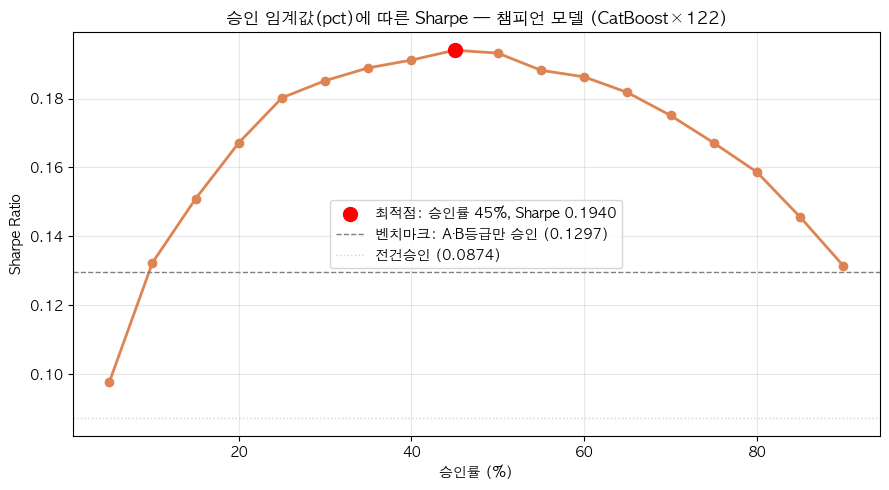

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

result_champion, best_champion = sweep_threshold(pred_tree122, excess_val)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(result_champion["pct"] * 100, result_champion["sharpe"], marker="o", color="#DD8452", linewidth=2)

ax.scatter(best_champion["pct"] * 100, best_champion["sharpe"], color="red", s=100, zorder=5,
           label=f"최적점: 승인률 {best_champion['pct']*100:.0f}%, Sharpe {best_champion['sharpe']:.4f}")

ax.axhline(0.1297, color="gray", linestyle="--", linewidth=1, label="벤치마크: A·B등급만 승인 (0.1297)")
ax.axhline(0.0874, color="lightgray", linestyle=":", linewidth=1, label="전건승인 (0.0874)")

ax.set_xlabel("승인률 (%)")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("승인 임계값(pct)에 따른 Sharpe — 챔피언 모델 (CatBoost×122)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_컷오프_전체Sharpe곡선.png", dpi=150, bbox_inches="tight")
plt.show()

#### 4-1. 해석 

x축은 "예측 점수 상위 몇 %를 승인할지", y축은 그때의 Sharpe. 곡선이 봉우리를 찍는 지점(빨간 점, **승인률 45%**)이 val 기준 최적 컷오프이며, 이 값을 test에도
그대로 고정 적용(더 이상 조정하지 않음). 회색 점선(0.1297)은 "LC A·B등급만 승인"했을 때의 성능으로, 전 구간에서 모델이 이를 상회하는 것을 확인할 수 있다.

#### 4-2. (참고) 등급별 배분 검토: 최종적으로 단일 컷오프 채택

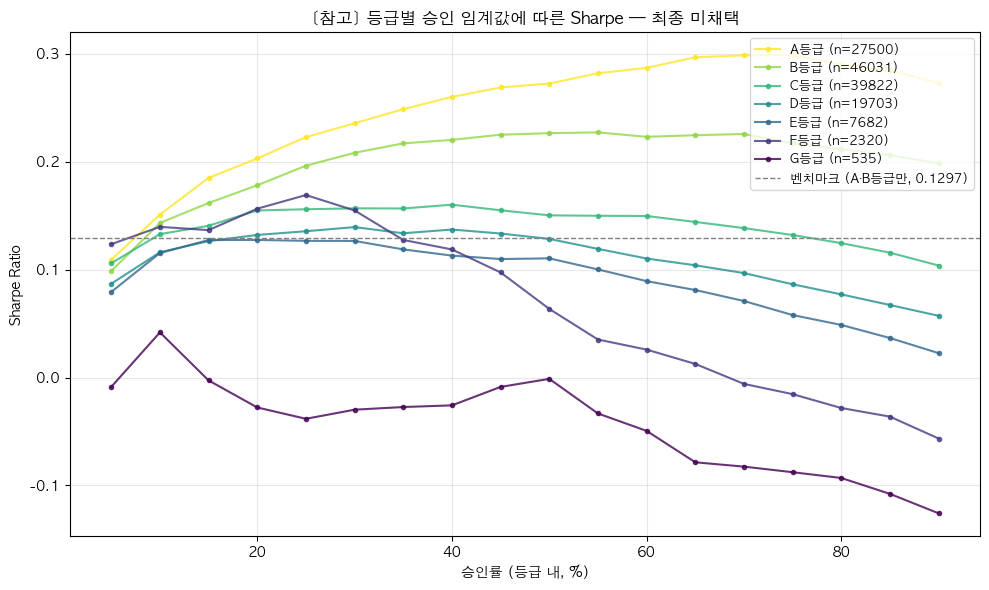

  등급  최적pct  최고Sharpe
0  A   0.75  0.298811
1  B   0.55  0.227180
2  C   0.40  0.160169
3  D   0.30  0.139410
4  E   0.20  0.127506
5  F   0.25  0.169113
6  G   0.10  0.041826


In [9]:
grades_order = ["A", "B", "C", "D", "E", "F", "G"]
colors = plt.cm.viridis_r(np.linspace(0, 1, len(grades_order)))

fig, ax = plt.subplots(figsize=(10, 6))
grade_best_points = []

for g, color in zip(grades_order, colors):
    mask = grade_val == g
    if mask.sum() == 0:
        continue
    result_g, best_g = sweep_threshold(pred_tree122[mask], excess_val[mask], verbose=False)
    ax.plot(result_g["pct"] * 100, result_g["sharpe"], marker="o", markersize=3,
            color=color, alpha=0.8, label=f"{g}등급 (n={mask.sum()})")
    grade_best_points.append({"등급": g, "최적pct": best_g["pct"], "최고Sharpe": best_g["sharpe"]})

ax.axhline(0.1297, color="gray", linestyle="--", linewidth=1, label="벤치마크 (A·B등급만, 0.1297)")

ax.set_xlabel("승인률 (등급 내, %)")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("[참고] 등급별 승인 임계값에 따른 Sharpe — 최종 미채택")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_참고_등급별Sharpe곡선.png", dpi=150, bbox_inches="tight")
plt.show()

grade_best_df = pd.DataFrame(grade_best_points)
print(grade_best_df)

#### 4-3. 해석: 왜 이 방식을 쓰지 않았는지

등급마다 곡선의 정점 위치가 다름을 확인했다(A등급은 승인률을 높여도 계속 상승, D·E등급은 초반에 정점 후 하락, G등급은 대체로 벤치마크 미달). 이에 따라 등급별로 각각 최적 pct를 적용해 포트폴리오를 구성해 보았으나, 그 결과 Sharpe는 **0.1930**으로 단일 컷오프(**0.1940**)보다 근소하게 낮았다. 각 등급을 개별적으로 최적화해도 전체 포트폴리오 관점에서는 최적이 아닐 수 있다는 확인이며, 이에 따라 **단일 컷오프(45%) 방식을 최종 채택**했다.

### 5. 기존 등급체계 대비 추가 선별력: 등급 내 부도 판별력(AUC)

In [11]:
from sklearn.metrics import roc_auc_score

def grade_auc_table(pred, bad, grade_arr, label, higher_is_bad=True):
    rows = []
    for g in sorted(pd.Series(grade_arr).unique()):
        mask = grade_arr == g
        if bad[mask].sum() == 0 or bad[mask].sum() == mask.sum():
            auc = None
        else:
            score = pred[mask] if higher_is_bad else -pred[mask]
            auc = roc_auc_score(bad[mask], score)
        rows.append({"등급": g, "n": mask.sum(), "AUC": round(auc, 4) if auc else None})
    return pd.DataFrame(rows)

table_auc = grade_auc_table(pred_tree122, bad_by_excess, grade_val, "챔피언", higher_is_bad=False)
print(table_auc)

  등급      n     AUC
0  A  27500  0.6331
1  B  46031  0.6272
2  C  39822  0.6185
3  D  19703  0.6089
4  E   7682  0.6144
5  F   2320  0.6276
6  G    535  0.5589


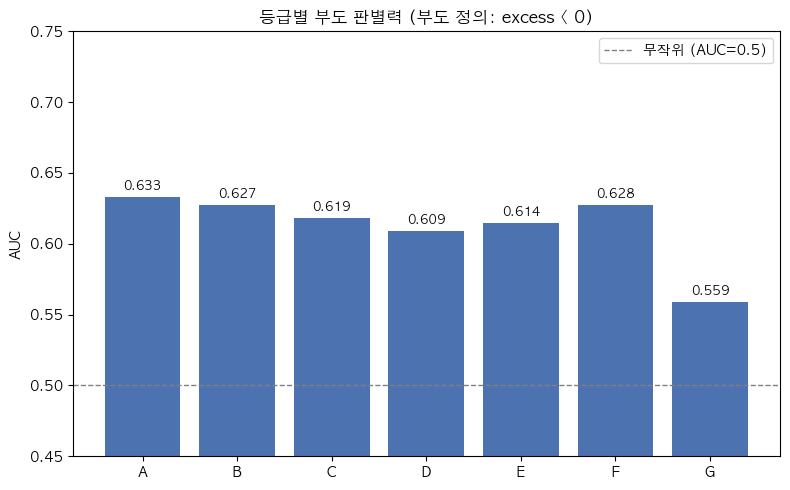

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(table_auc["등급"], table_auc["AUC"], color="#4C72B0")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="무작위 (AUC=0.5)")
ax.set_ylim(0.45, 0.75)
ax.set_ylabel("AUC")
ax.set_title("등급별 부도 판별력 (부도 정의: excess < 0)")
ax.legend()
for bar, val in zip(bars, table_auc["AUC"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("03_등급별_AUC.png", dpi=150, bbox_inches="tight")
plt.show()

#### 5-1. 해석 

AUC 0.5는 "무작위로 찍는 것"과 같은 수준을 의미한다(정확도 %가 아니라 순위 판별력 지표). LC가 이미 같은 등급으로 묶어둔 대출들 **안에서도**, 모델이 부도 위험을 무작위보다 뚜렷하게(A등급 0.633 ~ G등급 0.559) 구별해 낸다는 뜻. <br>
즉, LC 등급이 놓친 개별 차주 간 편차를, 본 모델이 추가로 포착하고 있음을 보여 준다. G등급은 표본이 작아(n=535) 다소 불안정할 수 있다. 

### 6. 승인건 부도율 비교: LC(등급 전체) vs 모델(선별 승인)
등급 내에서 pct% 승인했을 때, 승인건들의 실제 부도율을 등급 전체 부도율과 비교한다.

In [ ]:
def approved_bad_rate_by_grade(pred, bad, grade_arr, pct=0.45):
    rows = []
    for g in sorted(pd.Series(grade_arr).unique()):
        mask = grade_arr == g
        pred_g, bad_g = pred[mask], bad[mask]
        thr = np.quantile(pred_g, 1 - pct)
        approved = pred_g >= thr

        lc_bad_rate = bad_g.mean()
        model_bad_rate = bad_g[approved].mean()

        rows.append({
            "등급": g, "승인건수": approved.sum(), "전체건수": mask.sum(),
            "LC(등급전체) 부도율": round(lc_bad_rate, 4),
            "모델(승인건만) 부도율": round(model_bad_rate, 4),
            "개선폭": round(lc_bad_rate - model_bad_rate, 4),
        })
    return pd.DataFrame(rows)

table_approved = approved_bad_rate_by_grade(pred_tree122, bad_by_excess, grade_val, pct=0.45)
print(table_approved)

  등급   승인건수   전체건수  LC(등급전체) 부도율  모델(승인건만) 부도율     개선폭
0  A  12375  27500        0.0547        0.0352  0.0195
1  B  20714  46031        0.1097        0.0723  0.0373
2  C  17920  39822        0.1729        0.1212  0.0517
3  D   8866  19703        0.2271        0.1666  0.0605
4  E   3457   7682        0.2714        0.2025  0.0689
5  F   1044   2320        0.3289        0.2289  0.1000
6  G    241    535        0.3813        0.3278  0.0535


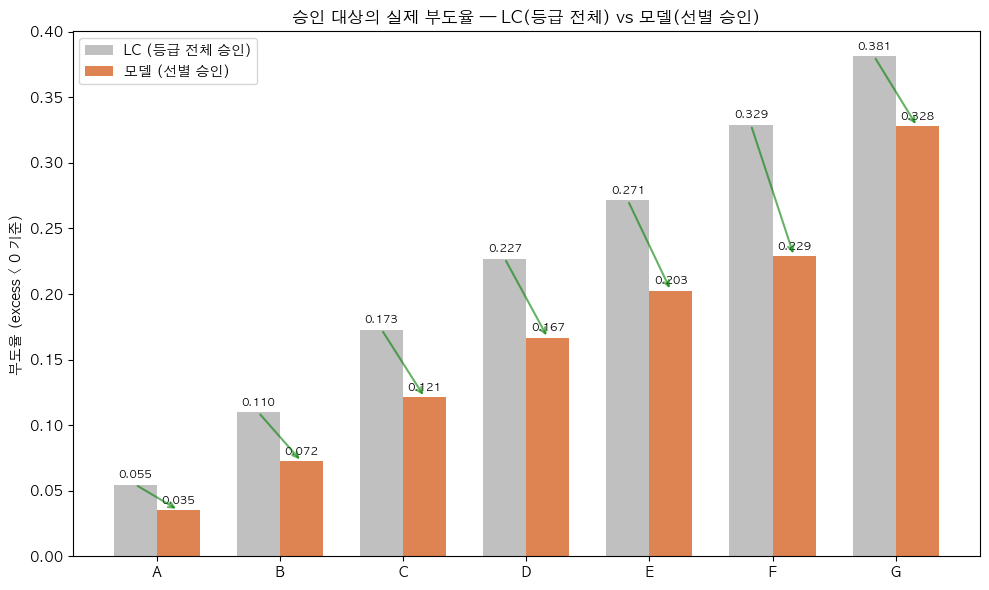

In [14]:
grades = table_approved["등급"]
x = np.arange(len(grades))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, table_approved["LC(등급전체) 부도율"], width,
                label="LC (등급 전체 승인)", color="#C0C0C0")
bars2 = ax.bar(x + width/2, table_approved["모델(승인건만) 부도율"], width,
                label="모델 (선별 승인)", color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(grades)
ax.set_ylabel("부도율 (excess < 0 기준)")
ax.set_title("승인 대상의 실제 부도율 — LC(등급 전체) vs 모델(선별 승인)")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}", ha="center", fontsize=8)

for i, row in table_approved.iterrows():
    ax.annotate("", xy=(i + width/2, row["모델(승인건만) 부도율"]),
                xytext=(i - width/2, row["LC(등급전체) 부도율"]),
                arrowprops=dict(arrowstyle="->", color="green", lw=1.5, alpha=0.6))

plt.tight_layout()
plt.savefig("04_승인건_부도율_비교.png", dpi=150, bbox_inches="tight")
plt.show()

#### 6-1. 해석

회색 막대는 "LC가 그 등급을 통째로 승인했을 때"의 실제 부도율, 주황 막대는 "모델이 그 등급 안에서 <u>상위 45%만 선별 승인</u>했을 때"의 실제 부도율이다. **전 등급에서 주황이 회색보다 낮게 나왔으며**, 특히 F등급에서 개선폭이 가장 컸다(부도율 약 10%p 감소). 이는 모델 기반 선별이 LC의 등급 심사만 따르는 것보다 실제로 더 안전한 포트폴리오를 구성한다는 근거가 된다.

### 7. 재분류 분석: LC 등급 대비 모델 등급 재배치
등급 비중(누적 quantile)에 맞춰 모델 등급을 동일 비율로 구성하였다.

In [15]:
# LC 등급 비중 (step1 실측)
LC_W = [0.1913, 0.3176, 0.2782, 0.1368, 0.0551, 0.0170, 0.0040]
cuts = np.cumsum(LC_W)[:-1]

q = np.quantile(pred_tree122, 1 - cuts)
model_grade_weighted = np.digitize(-pred_tree122, -np.r_[np.inf, q, -np.inf][1:-1])

grade_labels = ["A'(최고)", "B'", "C'", "D'", "E'", "F'", "G'(최저)"]
model_grade_weighted_named = pd.Series(model_grade_weighted).map(dict(enumerate(grade_labels)))

print("비중 맞춘 모델 등급별 건수:")
print(model_grade_weighted_named.value_counts().reindex(grade_labels))
print("\nLC 등급별 건수 (비교용):")
print(pd.Series(grade_val).value_counts().reindex(grades_order))

비중 맞춘 모델 등급별 건수:
A'(최고)    27470
B'        45604
C'        39948
D'        19643
E'         7912
F'         2441
G'(최저)      575
Name: count, dtype: int64

LC 등급별 건수 (비교용):
A    27500
B    46031
C    39822
D    19703
E     7682
F     2320
G      535
Name: count, dtype: int64


**참고**: 단순히 예측값을 7등분(균등 14.3%씩)하지 않고, **LC 등급의 실제 비중** (A 19.1%, B 31.8%, C 27.8%, D 13.7%, E 5.5%, F 1.7%, G 0.4%)과 **동일한 비율**로 모델 등급을 나눴다. 그래야 같은 규모의 그룹끼리 비교되어 공정해짐.

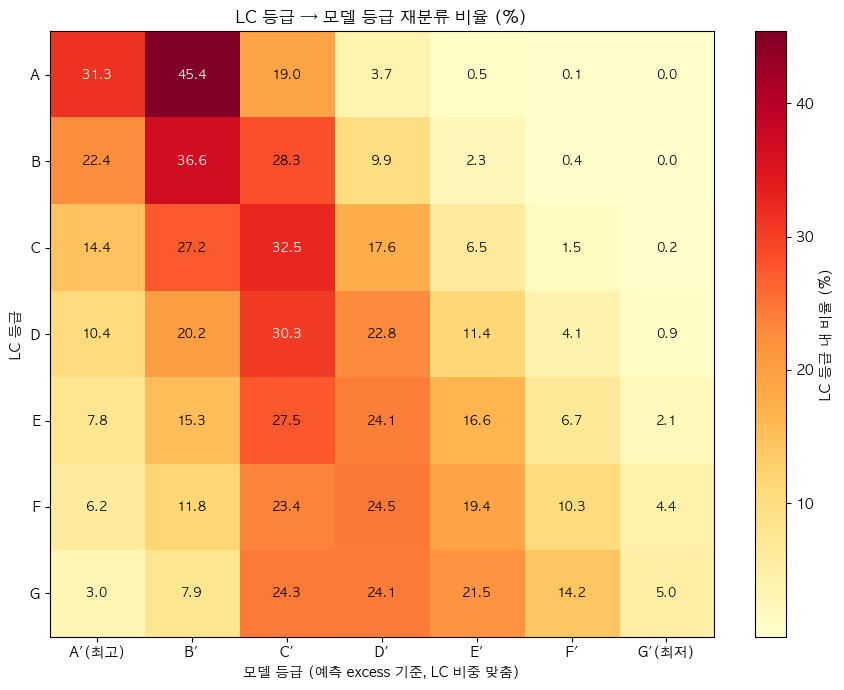

In [16]:
model_order = grade_labels
crosstab = pd.crosstab(grade_val, model_grade_weighted_named)
crosstab_ordered = crosstab.reindex(index=grades_order, columns=model_order)
crosstab_pct = crosstab_ordered.div(crosstab_ordered.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(crosstab_pct.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(np.arange(len(model_order)))
ax.set_yticks(np.arange(len(grades_order)))
ax.set_xticklabels(model_order)
ax.set_yticklabels(grades_order)
ax.set_xlabel("모델 등급 (예측 excess 기준, LC 비중 맞춤)")
ax.set_ylabel("LC 등급")
ax.set_title("LC 등급 → 모델 등급 재분류 비율 (%)")

for i in range(len(grades_order)):
    for j in range(len(model_order)):
        val = crosstab_pct.values[i, j]
        text_color = "white" if val > 30 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", color=text_color, fontsize=9)

fig.colorbar(im, ax=ax, label="LC 등급 내 비율 (%)")
plt.tight_layout()
plt.savefig("05_LC_모델등급_재분류_히트맵.png", dpi=150, bbox_inches="tight")
plt.show()

#### 7-1. 해석 

행(LC등급)을 따라 읽으면 됨:
<br> 예를 들어 **LC C등급 대출은 모델 재분류 시 A'~G' 전 구간에 걸쳐 10~18%씩 고르게 분산**되어 있으며, 특정 모델 등급으로의 쏠림이 없다. 이는 LC가 "C등급"이라는 하나의 라벨로 묶은 대출 안에 실제로는 최우량(A')부터 최하위(G')까지 섞여 있다는 뜻이며, **LC 등급 체계가 동일 등급 내 개별 차주의 위험도 편차를 충분히 반영하지 못하고 있음**을 보여주는 핵심 근거가 된다. 대각선(A-A', B-B' 등)에 값이 몰려 있지 않을수록 이 현상이 뚜렷하다.

## 최종 요약
**1. 효과 분해** <br>
챔피언 모델(CatBoost×122, pct=45%)은 val Sharpe 0.1940을 기록했다. 선형×47(0.1698) 대비 트리×122의 전체 격차(+0.0242)를 모형 효과(②−①, +0.0224, 95%CI [0.0160, 0.0276])와 변수 효과(③−②, +0.0019, 95%CI [−0.0027, 0.0059])로 분해한 결과, 성능 우위의 92.2%가 모델 구조에서 비롯되며 변수 개수 차이의 기여는 통계적으로 유의하지 않다. <br>

**2. 컷오프 선정** <br>
val Sharpe를 최대화하는 지점은 승인율 45%(Sharpe 0.1940)였다. 등급별로 컷오프를 따로 적용해봤으나 Sharpe 0.1930으로 단일 컷오프보다 낮아, 최종적으로 단일 컷오프(45%) 방식을 채택했다. <br>

**3. 등급 내 판별력** <br>
부도 정의(excess<0) 기준, 등급 내부 AUC는 A등급 0.633부터 G등급 0.559까지 전 등급에서 무작위(0.5)를 뚜렷하게 상회했다. LC가 이미 같은 등급으로 묶은 대출 안에서도 모델이 추가로 위험도를 구별해낸다는 뜻이다. <br>

**4. 승인건 부도율** <br>
등급 내에서 모델이 상위 45%만 선별 승인했을 때의 실제 부도율이 LC가 등급 전체를 승인했을 때보다 전 등급에서 낮았고, F등급에서 개선폭(약 10%p)이 가장 컸다. <br>

**5. 재분류 분석** <br>
LC 등급 비중에 맞춰 모델 등급을 재구성한 결과, 예를 들어 LC C등급 대출이 모델 재분류상 A'~G' 전 구간에 10~18%씩 고르게 분산되어 있었다. 이는 LC 등급이 동일 라벨 안의 개별 차주 간 위험도 편차를 충분히 반영하지 못한다는 근거다. <br>

<br>

> 종합: 챔피언 모델은 모형 구조 자체의 우위(변수 개수 아님)로 val Sharpe를 크게 개선했고, 이 우위는 전체 수준뿐 아니라 LC 등급 내부(판별력·부도율·재분류) 모든 층위에서 일관되게 확인되었다.